In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
from google.colab import files

uploaded = files.upload()

Saving customer_churn_business_dataset.csv to customer_churn_business_dataset.csv


In [4]:
import pandas as pd

df = pd.read_csv("/content/customer_churn_business_dataset.csv")

df.head()

,customer_id,gender,age,country,city,customer_segment,tenure_months,signup_channel,contract_type,monthly_logins,...,avg_resolution_time,complaint_type,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,survey_response,referral_count,churn
0,CUST_00001,Male,68,Bangladesh,London,SME,22,Web,Monthly,26,...,13.354360,Service,4.0,0,0.71,0.40,27,Satisfied,1,0
1,CUST_00002,Female,57,Canada,Sydney,Individual,9,Mobile,Monthly,7,...,25.140088,Billing,2.0,0,0.78,0.33,-19,Neutral,2,1
2,CUST_00003,Male,24,Germany,New York,SME,58,Web,Yearly,19,...,27.572928,Service,3.0,0,0.35,0.49,80,Neutral,1,0
3,CUST_00004,Male,49,Australia,Dhaka,Individual,19,Mobile,Yearly,34,...,26.420822,Technical,5.0,1,0.83,0.15,100,Neutral,0,0
4,CUST_00005,Male,65,Bangladesh,Delhi,Individual,52,Web,Monthly,20,...,26.674579,Technical,4.0,0,0.65,0.44,21,Unsatisfied,1,0


In [5]:
df.shape

(10000, 32)

In [6]:
df.columns

Index(['customer_id', 'gender', 'age', 'country', 'city', 'customer_segment',
       'tenure_months', 'signup_channel', 'contract_type', 'monthly_logins',
       'weekly_active_days', 'avg_session_time', 'features_used',
       'usage_growth_rate', 'last_login_days_ago', 'monthly_fee',
       'total_revenue', 'payment_method', 'payment_failures',
       'discount_applied', 'price_increase_last_3m', 'support_tickets',
       'avg_resolution_time', 'complaint_type', 'csat_score', 'escalations',
       'email_open_rate', 'marketing_click_rate', 'nps_score',
       'survey_response', 'referral_count', 'churn'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             10000 non-null  object 
 1   gender                  10000 non-null  object 
 2   age                     10000 non-null  int64  
 3   country                 10000 non-null  object 
 4   city                    10000 non-null  object 
 5   customer_segment        10000 non-null  object 
 6   tenure_months           10000 non-null  int64  
 7   signup_channel          10000 non-null  object 
 8   contract_type           10000 non-null  object 
 9   monthly_logins          10000 non-null  int64  
 10  weekly_active_days      10000 non-null  int64  
 11  avg_session_time        10000 non-null  float64
 12  features_used           10000 non-null  int64  
 13  usage_growth_rate       10000 non-null  float64
 14  last_login_days_ago     10000 non-null 

In [8]:
df = df.drop_duplicates()

In [9]:
df.dtypes

,0
customer_id,object
gender,object
age,int64
country,object
city,object
customer_segment,object
tenure_months,int64
signup_channel,object
contract_type,object
monthly_logins,int64


In [10]:
df.columns = df.columns.str.strip()

print(df.columns.tolist())

['customer_id', 'gender', 'age', 'country', 'city', 'customer_segment', 'tenure_months', 'signup_channel', 'contract_type', 'monthly_logins', 'weekly_active_days', 'avg_session_time', 'features_used', 'usage_growth_rate', 'last_login_days_ago', 'monthly_fee', 'total_revenue', 'payment_method', 'payment_failures', 'discount_applied', 'price_increase_last_3m', 'support_tickets', 'avg_resolution_time', 'complaint_type', 'csat_score', 'escalations', 'email_open_rate', 'marketing_click_rate', 'nps_score', 'survey_response', 'referral_count', 'churn']


In [11]:
[col for col in df.columns if "total" in col.lower()]

['total_revenue']

In [12]:
df["total_revenue"] = pd.to_numeric(
    df["total_revenue"],
    errors="coerce"
)

In [13]:
df["total_revenue"].isnull().sum()

np.int64(0)

In [14]:
df.head()

,customer_id,gender,age,country,city,customer_segment,tenure_months,signup_channel,contract_type,monthly_logins,...,avg_resolution_time,complaint_type,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,survey_response,referral_count,churn
0,CUST_00001,Male,68,Bangladesh,London,SME,22,Web,Monthly,26,...,13.354360,Service,4.0,0,0.71,0.40,27,Satisfied,1,0
1,CUST_00002,Female,57,Canada,Sydney,Individual,9,Mobile,Monthly,7,...,25.140088,Billing,2.0,0,0.78,0.33,-19,Neutral,2,1
2,CUST_00003,Male,24,Germany,New York,SME,58,Web,Yearly,19,...,27.572928,Service,3.0,0,0.35,0.49,80,Neutral,1,0
3,CUST_00004,Male,49,Australia,Dhaka,Individual,19,Mobile,Yearly,34,...,26.420822,Technical,5.0,1,0.83,0.15,100,Neutral,0,0
4,CUST_00005,Male,65,Bangladesh,Delhi,Individual,52,Web,Monthly,20,...,26.674579,Technical,4.0,0,0.65,0.44,21,Unsatisfied,1,0


In [15]:
total_customers = len(df)

print("Total Customers:", total_customers)

Total Customers: 10000


In [16]:
print(df.columns.tolist())

['customer_id', 'gender', 'age', 'country', 'city', 'customer_segment', 'tenure_months', 'signup_channel', 'contract_type', 'monthly_logins', 'weekly_active_days', 'avg_session_time', 'features_used', 'usage_growth_rate', 'last_login_days_ago', 'monthly_fee', 'total_revenue', 'payment_method', 'payment_failures', 'discount_applied', 'price_increase_last_3m', 'support_tickets', 'avg_resolution_time', 'complaint_type', 'csat_score', 'escalations', 'email_open_rate', 'marketing_click_rate', 'nps_score', 'survey_response', 'referral_count', 'churn']


In [17]:
print(df.head())

  customer_id  gender  age     country      city customer_segment  \
0  CUST_00001    Male   68  Bangladesh    London              SME   
1  CUST_00002  Female   57      Canada    Sydney       Individual   
2  CUST_00003    Male   24     Germany  New York              SME   
3  CUST_00004    Male   49   Australia     Dhaka       Individual   
4  CUST_00005    Male   65  Bangladesh     Delhi       Individual   

   tenure_months signup_channel contract_type  monthly_logins  ...  \
0             22            Web       Monthly              26  ...   
1              9         Mobile       Monthly               7  ...   
2             58            Web        Yearly              19  ...   
3             19         Mobile        Yearly              34  ...   
4             52            Web       Monthly              20  ...   

   avg_resolution_time  complaint_type  csat_score  escalations  \
0            13.354360         Service         4.0            0   
1            25.140088        

In [18]:
[ch for ch in df.columns if "churn" in ch.lower()]

['churn']

In [19]:
df.columns = df.columns.str.strip()
print(df.columns.tolist())

['customer_id', 'gender', 'age', 'country', 'city', 'customer_segment', 'tenure_months', 'signup_channel', 'contract_type', 'monthly_logins', 'weekly_active_days', 'avg_session_time', 'features_used', 'usage_growth_rate', 'last_login_days_ago', 'monthly_fee', 'total_revenue', 'payment_method', 'payment_failures', 'discount_applied', 'price_increase_last_3m', 'support_tickets', 'avg_resolution_time', 'complaint_type', 'csat_score', 'escalations', 'email_open_rate', 'marketing_click_rate', 'nps_score', 'survey_response', 'referral_count', 'churn']


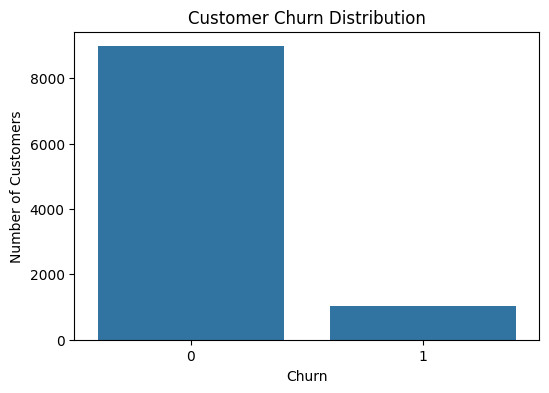

In [20]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [21]:
print(df.columns.tolist())

['customer_id', 'gender', 'age', 'country', 'city', 'customer_segment', 'tenure_months', 'signup_channel', 'contract_type', 'monthly_logins', 'weekly_active_days', 'avg_session_time', 'features_used', 'usage_growth_rate', 'last_login_days_ago', 'monthly_fee', 'total_revenue', 'payment_method', 'payment_failures', 'discount_applied', 'price_increase_last_3m', 'support_tickets', 'avg_resolution_time', 'complaint_type', 'csat_score', 'escalations', 'email_open_rate', 'marketing_click_rate', 'nps_score', 'survey_response', 'referral_count', 'churn']


In [22]:
df.columns = df.columns.str.strip()

print(df.columns.tolist())

['customer_id', 'gender', 'age', 'country', 'city', 'customer_segment', 'tenure_months', 'signup_channel', 'contract_type', 'monthly_logins', 'weekly_active_days', 'avg_session_time', 'features_used', 'usage_growth_rate', 'last_login_days_ago', 'monthly_fee', 'total_revenue', 'payment_method', 'payment_failures', 'discount_applied', 'price_increase_last_3m', 'support_tickets', 'avg_resolution_time', 'complaint_type', 'csat_score', 'escalations', 'email_open_rate', 'marketing_click_rate', 'nps_score', 'survey_response', 'referral_count', 'churn']


In [23]:
[col for col in df.columns if "churn" in col.lower()]

['churn']

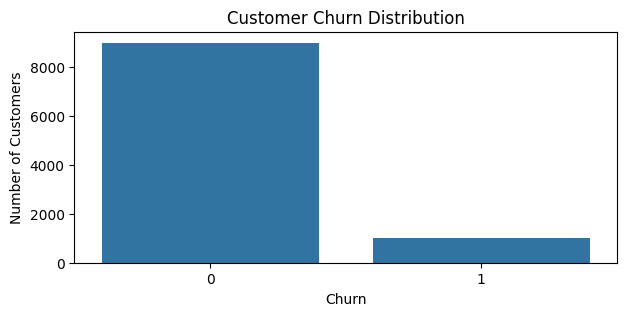

In [24]:
plt.figure(figsize=(7,3))

sns.countplot(
    data=df,
    x="churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [25]:
print([col for col in df.columns if "churn" in col.lower()])

['churn']


In [26]:
churn_col = [col for col in df.columns if "churn" in col.lower()][0]

print("Churn column found:", churn_col)

Churn column found: churn


In [27]:
churn_percentage = (
    df["churn"].value_counts(normalize=True) * 100
)

print(churn_percentage.round(2))

churn
0    89.79
1    10.21
Name: proportion, dtype: float64


In [28]:
df["churn"].value_counts()

,count
churn,
0,8979
1,1021


In [29]:
churn_percentage = df["churn"].value_counts(normalize=True) * 100

print(churn_percentage.round(2))

churn
0    89.79
1    10.21
Name: proportion, dtype: float64


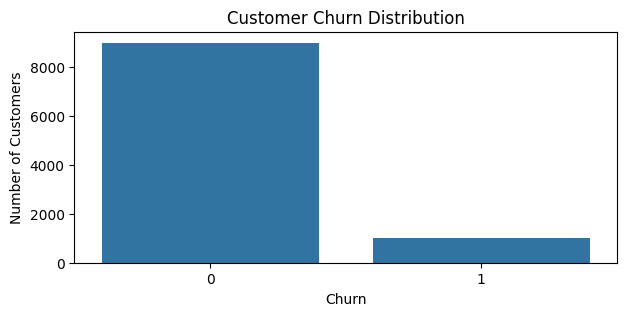

In [30]:
plt.figure(figsize=(7,3))

sns.countplot(
    data=df,
    x="churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [31]:
print(df.columns.tolist())

['customer_id', 'gender', 'age', 'country', 'city', 'customer_segment', 'tenure_months', 'signup_channel', 'contract_type', 'monthly_logins', 'weekly_active_days', 'avg_session_time', 'features_used', 'usage_growth_rate', 'last_login_days_ago', 'monthly_fee', 'total_revenue', 'payment_method', 'payment_failures', 'discount_applied', 'price_increase_last_3m', 'support_tickets', 'avg_resolution_time', 'complaint_type', 'csat_score', 'escalations', 'email_open_rate', 'marketing_click_rate', 'nps_score', 'survey_response', 'referral_count', 'churn']


In [32]:
pd.crosstab(
    df["gender"],
    df["churn"]
)

churn,0,1
gender,,
Female,4483,504
Male,4496,517


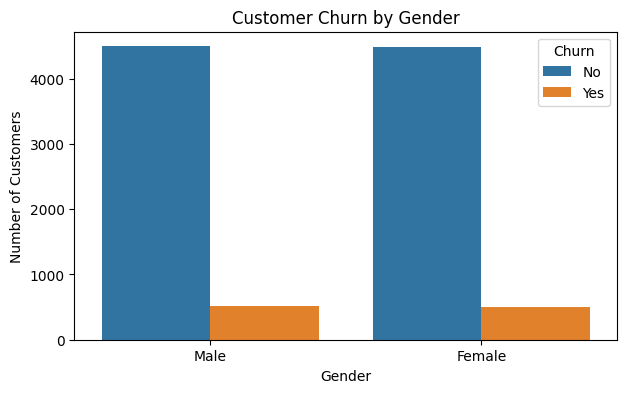

In [33]:
plt.figure(figsize=(7,4))

sns.countplot(
    data=df,
    x="gender",
    hue="churn"
)

plt.title("Customer Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.legend(title="Churn", labels=["No", "Yes"])

plt.show()

In [34]:
pd.crosstab(
    df["contract_type"],
    df["churn"]
)

churn,0,1
contract_type,,
Monthly,4454,513
Quarterly,2747,303
Yearly,1778,205


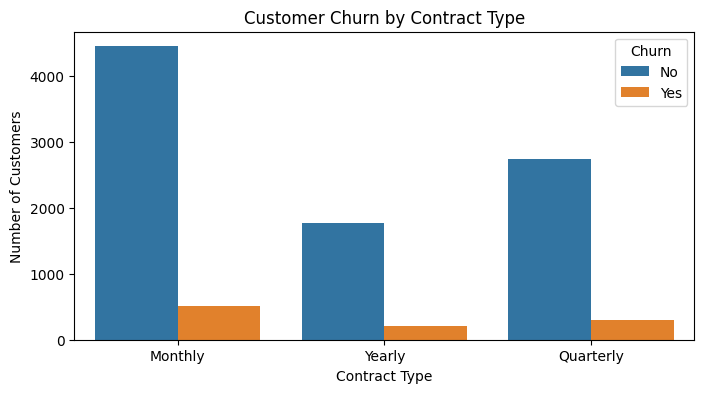

In [35]:
plt.figure(figsize=(8,4))

sns.countplot(
    data=df,
    x="contract_type",
    hue="churn"
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.legend(title="Churn", labels=["No", "Yes"])

plt.show()

In [36]:
contract_churn = pd.crosstab(
    df["contract_type"],
    df["churn"],
    normalize="index"
) * 100

print(contract_churn.round(2))

churn              0      1
contract_type              
Monthly        89.67  10.33
Quarterly      90.07   9.93
Yearly         89.66  10.34


In [37]:
pd.crosstab(
    df["payment_method"],
    df["churn"]
)

churn,0,1
payment_method,,
Bank Transfer,1341,147
Card,5336,619
PayPal,2302,255


In [38]:
payment_churn = pd.crosstab(
    df["payment_method"],
    df["churn"],
    normalize="index"
) * 100

print(payment_churn.round(2))

churn               0      1
payment_method              
Bank Transfer   90.12   9.88
Card            89.61  10.39
PayPal          90.03   9.97


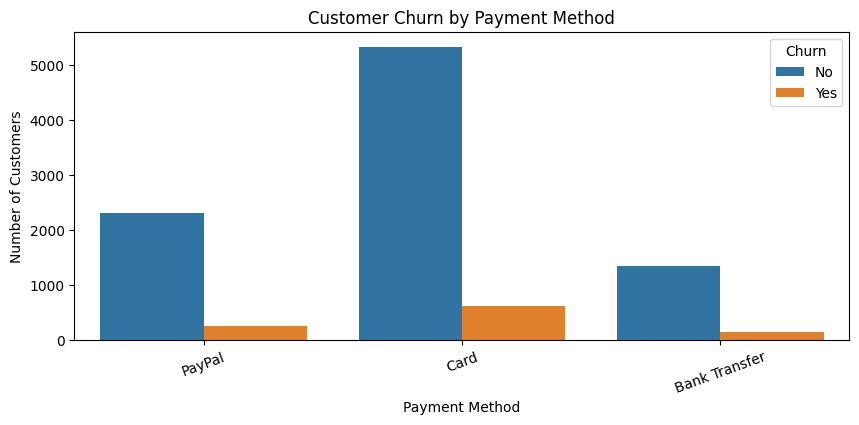

In [39]:
plt.figure(figsize=(10,4))

sns.countplot(
    data=df,
    x="payment_method",
    hue="churn"
)

plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)

plt.legend(title="Churn", labels=["No", "Yes"])

plt.show()

In [40]:
pd.crosstab(
    df["customer_segment"],
    df["churn"]
)

churn,0,1
customer_segment,,
Enterprise,894,93
Individual,5387,597
SME,2698,331


In [41]:
segment_churn = pd.crosstab(
    df["customer_segment"],
    df["churn"],
    normalize="index"
) * 100

print(segment_churn.round(2))

churn                 0      1
customer_segment              
Enterprise        90.58   9.42
Individual        90.02   9.98
SME               89.07  10.93


In [42]:
pd.crosstab(
    df["signup_channel"],
    df["churn"]
)

churn,0,1
signup_channel,,
Mobile,2664,296
Referral,1780,224
Web,4535,501


In [43]:
signup_churn = pd.crosstab(
    df["signup_channel"],
    df["churn"],
    normalize="index"
) * 100

print(signup_churn.round(2))

churn               0      1
signup_channel              
Mobile          90.00  10.00
Referral        88.82  11.18
Web             90.05   9.95


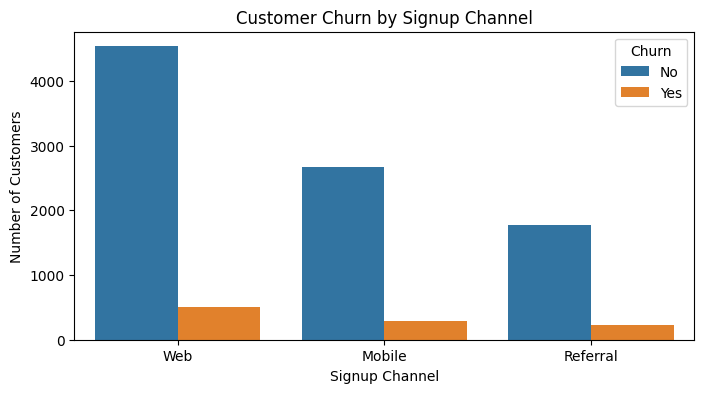

In [44]:
plt.figure(figsize=(8,4))

sns.countplot(
    data=df,
    x="signup_channel",
    hue="churn"
)

plt.title("Customer Churn by Signup Channel")
plt.xlabel("Signup Channel")
plt.ylabel("Number of Customers")

plt.legend(title="Churn", labels=["No", "Yes"])

plt.show()

In [45]:
pd.crosstab(
    df["country"],
    df["churn"]
)

churn,0,1
country,,
Australia,1248,152
Bangladesh,1354,140
Canada,1336,152
Germany,1210,157
India,1296,131
UK,1239,143
USA,1296,146


In [46]:
country_churn = pd.crosstab(
    df["country"],
    df["churn"],
    normalize="index"
) * 100

print(country_churn.round(2))

churn           0      1
country                 
Australia   89.14  10.86
Bangladesh  90.63   9.37
Canada      89.78  10.22
Germany     88.51  11.49
India       90.82   9.18
UK          89.65  10.35
USA         89.88  10.12


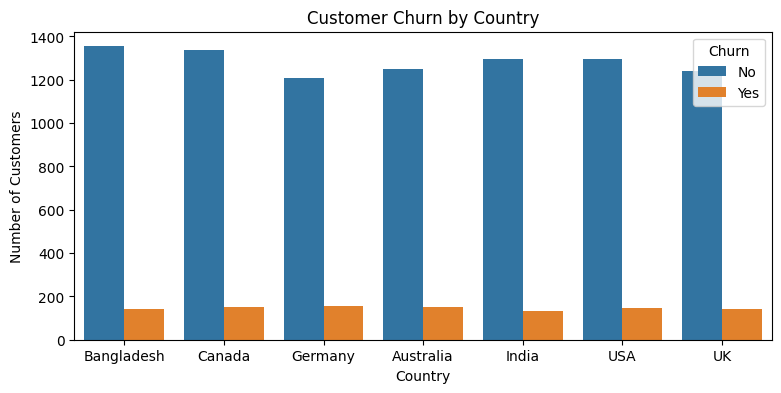

In [47]:
plt.figure(figsize=(9,4))

sns.countplot(
    data=df,
    x="country",
    hue="churn"
)

plt.title("Customer Churn by Country")
plt.xlabel("Country")
plt.ylabel("Number of Customers")

plt.legend(title="Churn", labels=["No", "Yes"])

plt.show()

In [48]:
df["tenure_months"].describe()

,tenure_months
count,10000.000000
mean,30.155700
std,17.099517
min,1.000000
25%,16.000000
50%,30.000000
75%,45.000000
max,59.000000


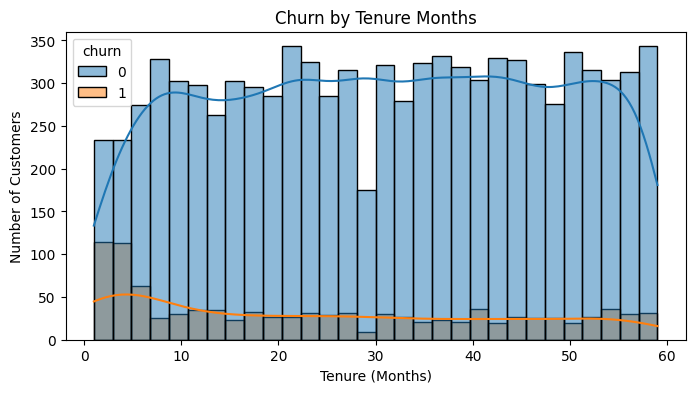

In [49]:
plt.figure(figsize=(8,4))

sns.histplot(
    data=df,
    x="tenure_months",
    hue="churn",
    bins=30,
    kde=True
)

plt.title("Churn by Tenure Months")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

In [50]:
df.groupby("churn")["tenure_months"].mean().round(2)

,tenure_months
churn,
0,30.83
1,24.22


In [51]:
df.groupby("churn")["monthly_fee"].mean().round(2)

,monthly_fee
churn,
0,34.97
1,34.57


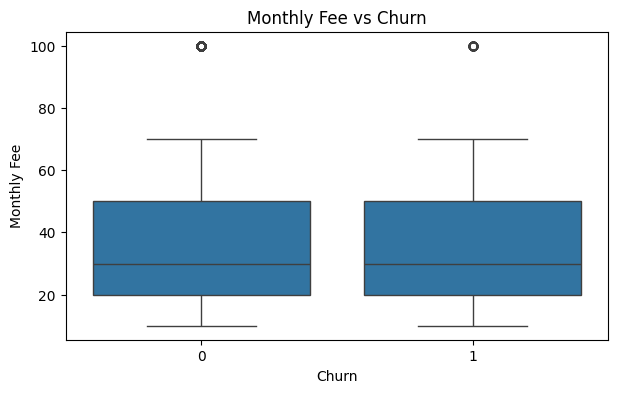

In [52]:
plt.figure(figsize=(7,4))

sns.boxplot(
    data=df,
    x="churn",
    y="monthly_fee"
)

plt.title("Monthly Fee vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Fee")

plt.show()

In [53]:
df.groupby("churn")["total_revenue"].mean().round(2)

,total_revenue
churn,
0,1081.14
1,844.90


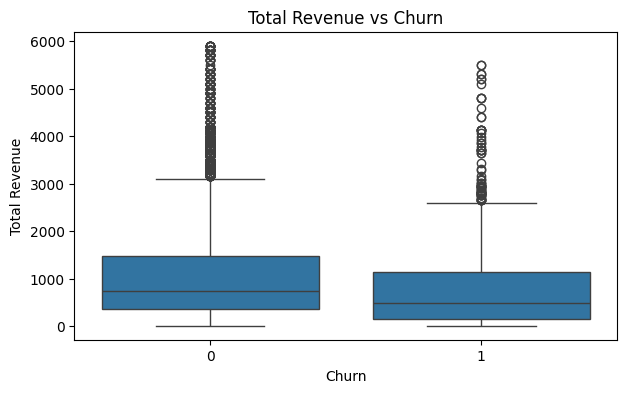

In [54]:
plt.figure(figsize=(7,4))

sns.boxplot(
    data=df,
    x="churn",
    y="total_revenue"
)

plt.title("Total Revenue vs Churn")
plt.xlabel("Churn")
plt.ylabel("Total Revenue")

plt.show()

In [55]:
df.groupby("churn")["age"].mean().round(2)

,age
churn,
0,45.85
1,46.40


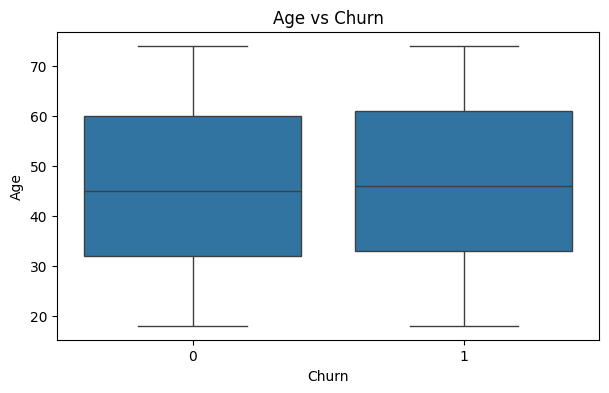

In [56]:
plt.figure(figsize=(7,4))

sns.boxplot(
    data=df,
    x="churn",
    y="age"
)

plt.title("Age vs Churn")
plt.xlabel("Churn")
plt.ylabel("Age")

plt.show()

In [57]:
numeric_df = df.select_dtypes(include="number")

numeric_df.head()

,age,tenure_months,monthly_logins,weekly_active_days,avg_session_time,features_used,usage_growth_rate,last_login_days_ago,monthly_fee,total_revenue,payment_failures,support_tickets,avg_resolution_time,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,referral_count,churn
0,68,22,26,7,11.762372,5,0.06,7,30,660,1,4,13.354360,4.0,0,0.71,0.40,27,1,0
1,57,9,7,5,26.846390,1,-0.28,2,30,270,1,1,25.140088,2.0,0,0.78,0.33,-19,2,1
2,24,58,19,5,23.380065,6,0.13,23,20,1160,2,1,27.572928,3.0,0,0.35,0.49,80,1,0
3,49,19,34,7,24.243136,2,-0.17,24,30,570,0,3,26.420822,5.0,1,0.83,0.15,100,0,0
4,65,52,20,6,18.872323,2,-0.16,2,50,2600,0,0,26.674579,4.0,0,0.65,0.44,21,1,0


In [58]:
numeric_df = df.select_dtypes(include="number")

numeric_df.head()

,age,tenure_months,monthly_logins,weekly_active_days,avg_session_time,features_used,usage_growth_rate,last_login_days_ago,monthly_fee,total_revenue,payment_failures,support_tickets,avg_resolution_time,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,referral_count,churn
0,68,22,26,7,11.762372,5,0.06,7,30,660,1,4,13.354360,4.0,0,0.71,0.40,27,1,0
1,57,9,7,5,26.846390,1,-0.28,2,30,270,1,1,25.140088,2.0,0,0.78,0.33,-19,2,1
2,24,58,19,5,23.380065,6,0.13,23,20,1160,2,1,27.572928,3.0,0,0.35,0.49,80,1,0
3,49,19,34,7,24.243136,2,-0.17,24,30,570,0,3,26.420822,5.0,1,0.83,0.15,100,0,0
4,65,52,20,6,18.872323,2,-0.16,2,50,2600,0,0,26.674579,4.0,0,0.65,0.44,21,1,0


In [59]:
numeric_df = df.select_dtypes(include="number")

numeric_df.head()

,age,tenure_months,monthly_logins,weekly_active_days,avg_session_time,features_used,usage_growth_rate,last_login_days_ago,monthly_fee,total_revenue,payment_failures,support_tickets,avg_resolution_time,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,referral_count,churn
0,68,22,26,7,11.762372,5,0.06,7,30,660,1,4,13.354360,4.0,0,0.71,0.40,27,1,0
1,57,9,7,5,26.846390,1,-0.28,2,30,270,1,1,25.140088,2.0,0,0.78,0.33,-19,2,1
2,24,58,19,5,23.380065,6,0.13,23,20,1160,2,1,27.572928,3.0,0,0.35,0.49,80,1,0
3,49,19,34,7,24.243136,2,-0.17,24,30,570,0,3,26.420822,5.0,1,0.83,0.15,100,0,0
4,65,52,20,6,18.872323,2,-0.16,2,50,2600,0,0,26.674579,4.0,0,0.65,0.44,21,1,0


In [60]:
correlation = numeric_df.corr()

correlation

,age,tenure_months,monthly_logins,weekly_active_days,avg_session_time,features_used,usage_growth_rate,last_login_days_ago,monthly_fee,total_revenue,payment_failures,support_tickets,avg_resolution_time,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,referral_count,churn
age,1.000000,0.022712,-0.010887,-0.001722,-0.000246,-0.003056,-0.003532,-0.000863,0.009351,0.022291,-0.009963,0.007973,-0.019960,0.003199,0.002682,-0.003897,0.004131,-0.000025,0.015263,0.010155
tenure_months,0.022712,1.000000,-0.006003,0.004488,0.039701,-0.005822,0.009197,0.014857,0.009048,0.589513,0.004230,-0.007263,-0.003774,-0.011396,-0.001270,0.018275,-0.002061,0.008826,0.007233,-0.117014
monthly_logins,-0.010887,-0.006003,1.000000,0.026486,0.003385,0.013586,-0.014874,0.005402,-0.017664,-0.016617,0.014369,-0.016726,-0.005035,-0.001835,0.001790,0.000535,0.003174,-0.003618,-0.003586,-0.098339
weekly_active_days,-0.001722,0.004488,0.026486,1.000000,0.008504,-0.004142,-0.014688,-0.005151,-0.000172,0.004571,-0.008835,0.010326,0.014109,0.013306,0.008004,0.002491,0.003747,-0.007607,-0.002474,-0.008818
avg_session_time,-0.000246,0.039701,0.003385,0.008504,1.000000,0.006494,-0.012595,0.000633,0.002608,0.020195,-0.017167,0.006712,-0.003416,-0.011819,0.007553,-0.018362,-0.013897,-0.000842,-0.007908,-0.004659
features_used,-0.003056,-0.005822,0.013586,-0.004142,0.006494,1.000000,0.017934,0.001714,-0.011800,-0.012519,0.009089,-0.006960,-0.009561,-0.005186,-0.024638,-0.014928,-0.006410,0.008380,-0.003445,0.005435
usage_growth_rate,-0.003532,0.009197,-0.014874,-0.014688,-0.012595,0.017934,1.000000,0.006923,-0.012855,0.002906,-0.018154,-0.000792,0.006083,-0.019604,0.009364,0.014329,0.012297,0.003628,-0.017798,0.005276
last_login_days_ago,-0.000863,0.014857,0.005402,-0.005151,0.000633,0.001714,0.006923,1.000000,-0.009309,0.002198,0.016499,-0.018653,-0.002638,-0.007267,-0.002702,-0.002535,-0.009630,0.001907,-0.001095,0.037250
monthly_fee,0.009351,0.009048,-0.017664,-0.000172,0.002608,-0.011800,-0.012855,-0.009309,1.000000,0.708507,0.005851,0.004852,0.011625,0.009176,-0.010211,0.023292,0.003718,-0.009983,0.010849,-0.005048
total_revenue,0.022291,0.589513,-0.016617,0.004571,0.020195,-0.012519,0.002906,0.002198,0.708507,1.000000,0.013869,0.000830,0.008864,0.001061,-0.007443,0.028429,-0.005620,0.007512,0.011019,-0.070120


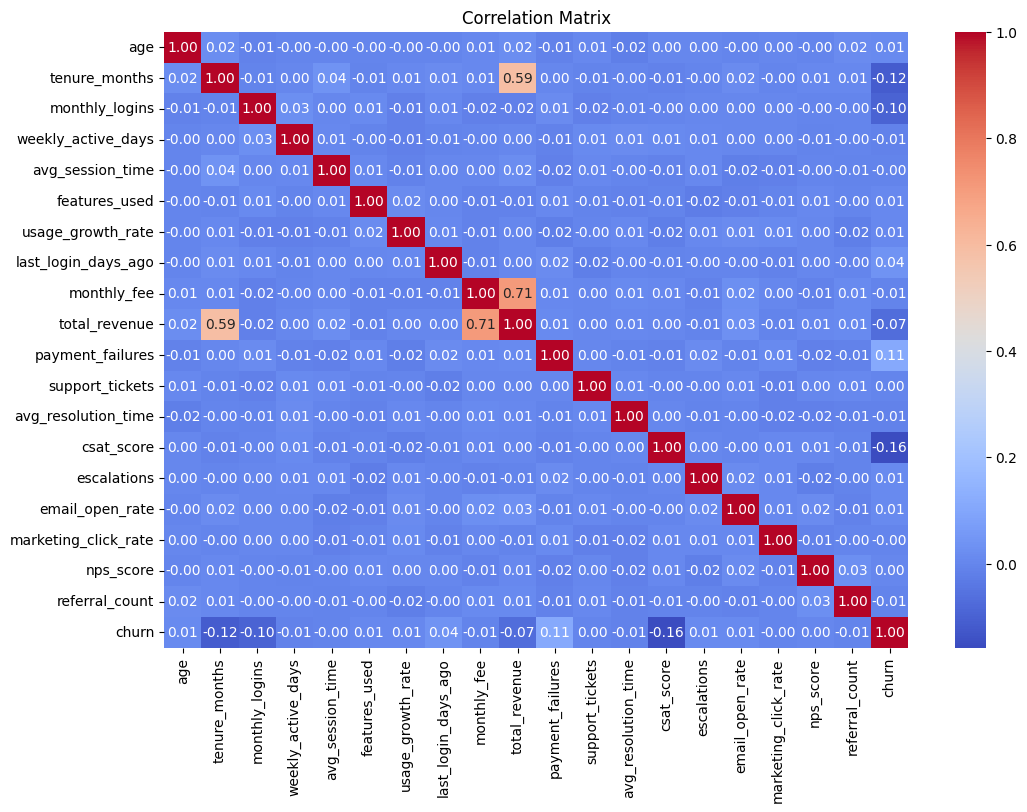

In [61]:
plt.figure(figsize=(12,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [62]:
df.dtypes

,0
customer_id,object
gender,object
age,int64
country,object
city,object
customer_segment,object
tenure_months,int64
signup_channel,object
contract_type,object
monthly_logins,int64


In [63]:
df_ml = pd.get_dummies(
    df,
    drop_first=True
)

df_ml.head()

,age,tenure_months,monthly_logins,weekly_active_days,avg_session_time,features_used,usage_growth_rate,last_login_days_ago,monthly_fee,total_revenue,...,contract_type_Quarterly,contract_type_Yearly,payment_method_Card,payment_method_PayPal,discount_applied_Yes,price_increase_last_3m_Yes,complaint_type_Service,complaint_type_Technical,survey_response_Satisfied,survey_response_Unsatisfied
0,68,22,26,7,11.762372,5,0.06,7,30,660,...,False,False,False,True,True,False,True,False,True,False
1,57,9,7,5,26.846390,1,-0.28,2,30,270,...,False,False,True,False,False,True,False,False,False,False
2,24,58,19,5,23.380065,6,0.13,23,20,1160,...,False,True,True,False,False,False,True,False,False,False
3,49,19,34,7,24.243136,2,-0.17,24,30,570,...,False,True,False,False,True,False,False,True,False,False
4,65,52,20,6,18.872323,2,-0.16,2,50,2600,...,False,False,False,True,False,False,False,True,False,True


In [64]:
df_ml = pd.get_dummies(
    df,
    drop_first=True
)

df_ml.head()

,age,tenure_months,monthly_logins,weekly_active_days,avg_session_time,features_used,usage_growth_rate,last_login_days_ago,monthly_fee,total_revenue,...,contract_type_Quarterly,contract_type_Yearly,payment_method_Card,payment_method_PayPal,discount_applied_Yes,price_increase_last_3m_Yes,complaint_type_Service,complaint_type_Technical,survey_response_Satisfied,survey_response_Unsatisfied
0,68,22,26,7,11.762372,5,0.06,7,30,660,...,False,False,False,True,True,False,True,False,True,False
1,57,9,7,5,26.846390,1,-0.28,2,30,270,...,False,False,True,False,False,True,False,False,False,False
2,24,58,19,5,23.380065,6,0.13,23,20,1160,...,False,True,True,False,False,False,True,False,False,False
3,49,19,34,7,24.243136,2,-0.17,24,30,570,...,False,True,False,False,True,False,False,True,False,False
4,65,52,20,6,18.872323,2,-0.16,2,50,2600,...,False,False,False,True,False,False,False,True,False,True


In [65]:
y = df_ml["churn"]

In [66]:
X = df_ml.drop(
    "churn",
    axis=1
)

In [67]:
print(X.shape)
print(y.shape)

(10000, 10045)
(10000,)


In [68]:
from sklearn.model_selection import train_test_split

In [69]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [70]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (8000, 10045)
X_test : (2000, 10045)
y_train: (8000,)
y_test : (2000,)


In [71]:
!pip install xgboost

In [72]:
from xgboost import XGBClassifier

In [73]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric="logloss"
)

In [74]:
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [75]:
y_pred = xgb_model.predict(X_test)

In [76]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))

Accuracy: 0.8925


In [77]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.99      0.94      1796
           1       0.35      0.06      0.11       204

    accuracy                           0.89      2000
   macro avg       0.63      0.53      0.53      2000
weighted avg       0.85      0.89      0.86      2000



In [78]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1772   24]
 [ 191   13]]


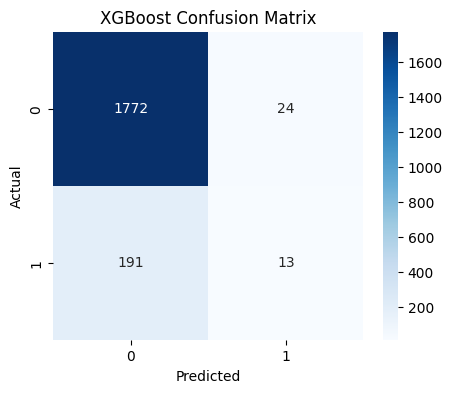

In [79]:
plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [80]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
13,csat_score,0.126315
10,payment_failures,0.070892
1,tenure_months,0.052923
2,monthly_logins,0.032816
10020,country_Canada,0.030030
10022,country_India,0.025086
10028,city_New York,0.023623
10019,country_Bangladesh,0.021530
7,last_login_days_ago,0.020908
10033,signup_channel_Referral,0.019137


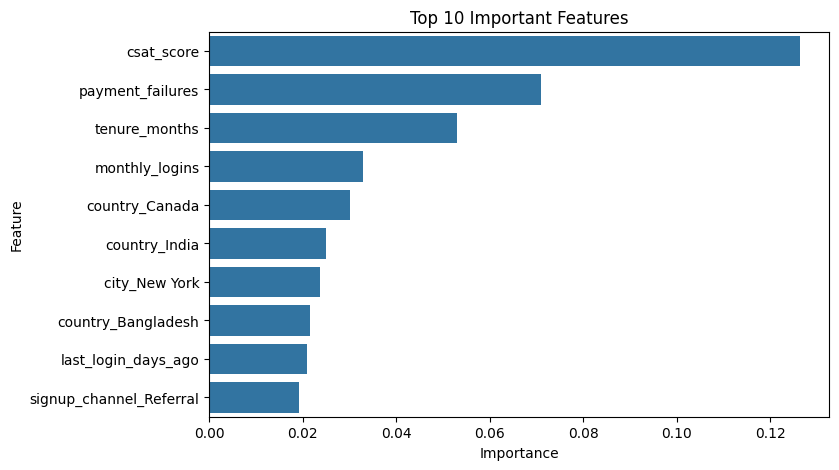

In [81]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")

plt.show()

In [82]:
import joblib

In [83]:
joblib.dump(xgb_model, "customer_churn_xgb.pkl")

['customer_churn_xgb.pkl']

In [84]:
import joblib

joblib.dump(xgb_model, "customer_churn_xgb.pkl")

['customer_churn_xgb.pkl']

In [85]:
from google.colab import files

files.download("customer_churn_xgb.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [86]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
13,csat_score,0.126315
10,payment_failures,0.070892
1,tenure_months,0.052923
2,monthly_logins,0.032816
10020,country_Canada,0.030030
10022,country_India,0.025086
10028,city_New York,0.023623
10019,country_Bangladesh,0.021530
7,last_login_days_ago,0.020908
10033,signup_channel_Referral,0.019137


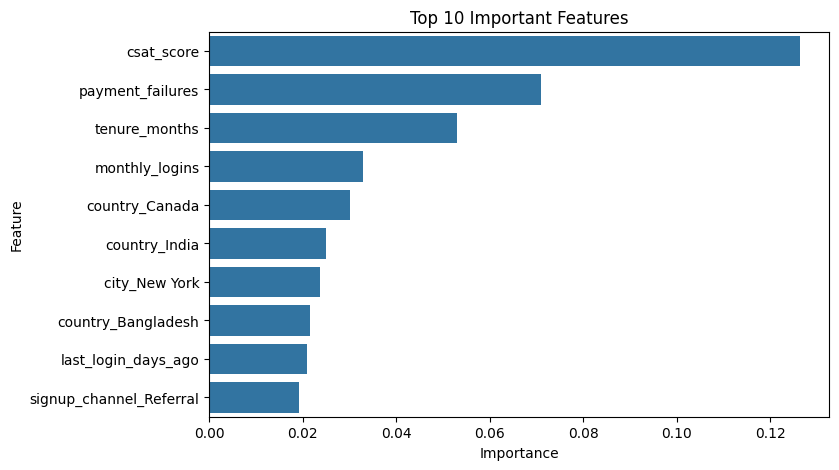

In [87]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")
plt.show()